<font size="+3"><strong>遺伝子単位での塩基配列データの準備</strong></font>

データを複数条件でフィルタリングし、配列情報を追加して出力する。

---

コード部分の最終更新日: 2024-08-26

 <font color="red" size="+1">注意事項：デバッグ不足</font>
 


---
---
# インポート
---

使いまわしているので、不要なライブラリのimportを含む。


In [1]:
# 汎用ライブラリのimport
import os
import sys
import copy
import warnings
import textwrap
from operator import itemgetter
from collections import Counter
import logging

import math
import random

import platform
import locale
import gzip
import io
import hashlib
import json
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib import __version__ as matplotlib_version

import sylib

# %config Completer.use_jedi = False
# %matplotlib inline

progress_bar = sylib.utils.ProgressBar()

# Jupyterでlog出力するための特殊な設定
# StreamHandlerの出力先としてsys.stderrを指定している。
logging.root.handlers = []
stream_handler = logging.StreamHandler(sys.stderr)
logging.basicConfig(
#     level=logging.DEBUG,
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler]
)
logger=logging.getLogger()

print("python = %d.%d.%d" % sys.version_info[:3])
print("pandas = %s" % pd.__version__)
print("numpy = %s" % np.__version__)
print("matplotlib = %s" % matplotlib_version)

print("sylib = %s" % sylib.__version__)


python = 3.11.9
pandas = 2.2.2
numpy = 1.26.4
matplotlib = 3.9.0
sylib = 0.3.0.dev0+ae18bb2


---
---
# 図の全体的な設定
---


In [2]:
# 一度図を作ってrcParamsを呼び込まないとrcParamsの変更が反映されない場合がある
fig = plt.figure()
plt.close()

# フォントサイズの指定です。
plt_font_size = 16
plt.rcParams['font.size'] = plt_font_size

# フォント名の指定です。フォントはインストールされているものに限ります。
# japanize_matplotlibを用いて日本語を表示している場合、
# フォントを不適切に再設定すると日本語が表示されなくなります。
# Colabを用いる場合はフォントのインストールや登録が必要となりハードルが高いです。
# Colabを用いる場合、初心者は変更せずに使いましょう。
# フォントを変更する場合は以下のコメントアウトを外してください。
# font.family以下はフォント名の設定を色々な要素に反映させるための記述です（変更不要）。
# plt.rcParams['font.serif'] = "DejaVu Sans"
# plt.rcParams['font.family'] = "serif"
# plt.rcParams['mathtext.cal'] = "serif:italic"
# plt.rcParams['mathtext.rm'] = "serif"
# plt.rcParams['mathtext.it'] = "serif:italic"
# plt.rcParams['mathtext.bf'] = "serif:bold"
# plt.rcParams['mathtext.fontset'] = "custom"

# グリッド線などを正しく表示するための設定です。
plt.rcParams['axes.axisbelow'] = True

# 図の解像度を上げるための設定です。
# 表示される図が大きくなるので動作をテストする際には小さい値のほうが見やすいです。
# 最終的に使用する図を出力する際には300など大きな数字を設定しましょう。
# 初期値は72です。
plt.rcParams["figure.dpi"] = 72
# plt.rcParams["figure.dpi"] = 300

# OKという表示があることを確認してください。
print("OK")


OK


---
---
# 出力フォルダの準備
---


In [3]:
output_dir = sylib.utils.make_dir("SeqData.Gene", should_clear=False)


---
---
# inputデータ形式の確認
---


---
## Unknown系列について

- unknown: 未知のスプライスバリアントのリード（5'/3'末端位置は想定されるTSS、CPSの範囲に存在する）
    - 未定義の転写産物であると考えられる
- extended5: 5'末端が想定されるTSSの範囲の上流に存在し、異常に長い5'UTR配列を有する（3'末端位置は想定されるCPSの範囲に存在する）
    - 上流遺伝子のリードスルー転写産物、遺伝子構造の定義エラー、DNAのコンタミ等の可能性が考えられる
- shortened5: 5'末端が想定されるTSSの範囲の下流に存在し、CDS内部に5'末端が存在する（3'末端位置は想定されるCPSの範囲に存在する）
    - 内部転写により生じた非コードRNA、遺伝子構造の定義エラー、分解中間産物、ライブラリ作製時のアーティファクトなどの可能性が考えられる
- extended3: 3'末端が想定されるCPSの範囲の上流に存在し、異常に長い3'UTR配列を有する（5'末端位置は想定されるCPSの範囲に存在する）
    - 遺伝子構造の定義エラー、DNAのコンタミ、リードスルー転写産物等の可能性が考えられる
- shortened3: 3'末端が想定されるCPSの範囲の下流に存在し、CDS内部に3'末端が存在する（5'末端位置は想定されるCPSの範囲に存在する）
    - 内部転写終結により生じた異常RNA、遺伝子構造の定義エラー、分解中間産物、ライブラリ作製時のアーティファクトなどの可能性が考えられる
- extended5and3: 未集計（DNAのコンタミ等の異常なリードである可能性が高い）
- shortened5and3: 未集計（分解中間産物等の異常なリードである可能性が高い）

---
## Geneデータについて

### rTrans-usage

- 最も主要なスプライスバリアントの存在比率（Unknownを除く）
- rTrans-usage.a: 使用頻度の計算時の分母は「既知のスプライスバリアント」
- rTrans-usage.b: 使用頻度の計算時の分母は「既知＋未知のスプライスバリアント」
- rTrans-usage.c: 使用頻度の計算時の分母は「既知＋未知のスプライスバリアント＋断片リード＋拡大リード」

### Unknown-usage

- 未知のスプライスバリアント（断片リードは除く）の存在比率
- Unknown-ratio.b: 使用頻度の計算時の分母は「既知＋未知のスプライスバリアント」
- Unknown-ratio.c: 使用頻度の計算時の分母は「既知＋未知のスプライスバリアント＋断片リード＋拡大リード」

### 5-exteded-ratio.cなど
- 断片や拡大リードの存在比率
- 5-exteded-ratio.c: 使用頻度の計算時の分母は「既知＋未知のスプライスバリアント＋断片リード＋拡大リード」

### rTSS-pos0b, rTSS-usage, rCPS-pos0b, rCPS-usage

- Unknownを除く、その遺伝子に属する全てのスプライスバリアントのTSSやCPSの分布を統合した上で、最も主要なサイトを定義し、そのサイトの存在比率を計算している
- rTSS系列とrCPS系列には全てのUnknown系列のデータが含まれていない（使用頻度の計算時の分母は「既知のスプライスバリアント」）

### rTrans-TSS-CPS-id, rTrans-TSS-CPS-usage

- 最も多く存在するスプライスバリアントの中で、最も頻出する5'末端と3'末端のペアの位置と、その遺伝子全体における比率
- これは、つまり細胞内に転写されているmRNAの中で最も出現頻度が高い配列のIDと、その存在比率を意味している
- 使用頻度のa系列: 使用頻度の計算時の分母は「既知のスプライスバリアント」
- 使用頻度のb系列: 使用頻度の計算時の分母は「既知＋未知のスプライスバリアント」
- 使用頻度のc系列: 使用頻度の計算時の分母は「既知＋未知のスプライスバリアント＋断片リード＋拡大リード」


In [4]:
file_path = os.path.join("AT22.PR.gene_data.tsv.gz")

data_df, metadata = sylib.fileio.load_df(
    file_path, encoding="utf-8",
    delimiter='\t', comment="#",
    header='infer', names=None, index_col=None,
)
metadata.print_data(label="Input data", logger=logger, logging_level="info")
display(data_df.head(10))

print(list(enumerate(data_df.columns)))

del data_df


2024-08-26 10:52:37,771     INFO: Input data |             name = AT22.PR.gene_data.tsv.gz
2024-08-26 10:52:37,772     INFO: Input data |              md5 = d6483936327cd270d3fb6758aec8a7d0
2024-08-26 10:52:37,772     INFO: Input data |           md5_gz = fc8a351b6e1bc49b73a92bf2ebb49c86
2024-08-26 10:52:37,773     INFO: Input data |   number_of_data = 16556
2024-08-26 10:52:37,773     INFO: Input data | column_name_list = ['gene_id', 'chrom', 'strand', 'PTPM', 'TPM', 'PR_gene', 'P_n_reads', 'T_n_reads', 'rTrans-id', 'rTrans-usage.a', 'rTrans-usage.b', 'rTrans-usage.c', 'Unknown-ratio.b', 'Unknown-ratio.c', '5-exteded-ratio.c', '5-shortened-ratio.c', '3-exteded-ratio.c', '3-shortened-ratio.c', 'rTSS-pos0b', 'rTSS-usage.a', 'rCPS-pos1b', 'rCPS-usage.a', 'rTrans-TSS-CPS-id', 'rTrans-TSS-CPS-usage.a', 'rTrans-TSS-CPS-usage.b', 'rTrans-TSS-CPS-usage.c', 'rTrans_coding_region', 'rTrans_ref_cigar_s0b', 'rTrans_ref_cigar']


,gene_id,chrom,strand,PTPM,TPM,PR_gene,P_n_reads,T_n_reads,rTrans-id,rTrans-usage.a,...,rTSS-usage.a,rCPS-pos1b,rCPS-usage.a,rTrans-TSS-CPS-id,rTrans-TSS-CPS-usage.a,rTrans-TSS-CPS-usage.b,rTrans-TSS-CPS-usage.c,rTrans_coding_region,rTrans_ref_cigar_s0b,rTrans_ref_cigar
0,AT1G01010,Chr1,+,0.304605,0.063154,4.910642,3,1,AT1G01010.1,1.000000,...,1.000000,5846,1.000000,"AT1G01010.1,3667,5846",1.000000,1.000000,0.076923,"[3759, 5630]",3630,283M82N281M209N120M100N390M78N153M112N461M
1,AT1G01020,Chr1,-,11.879610,11.178304,1.082006,117,177,AT1G01020.5,0.500000,...,0.125000,6856,0.285714,"AT1G01020.5,8680,6856",0.053571,0.016949,0.011407,"[6914, 8419]",6787,282M87N76M151N67M113N86M112N74M106N46M248N90M9...
2,AT1G01050,Chr1,-,265.006689,223.818706,1.205491,2610,3544,AT1G01050.1,1.000000,...,0.337855,31207,0.228730,"AT1G01050.1,33113,31207",0.077374,0.070824,0.054851,"[31381, 32670]",31169,255M96N82M90N121M119N66M89N108M86N66M83N29M87N...
3,AT1G01060,Chr1,-,0.000000,0.126309,0.000000,0,2,AT1G01060.2,0.500000,...,0.500000,33745,0.500000,"AT1G01060.2,37398,33761",0.500000,0.500000,0.090909,"[33991, 37061]",33665,662M73N1074M92N81M82N234M660N62M124N112M101N18...
4,AT1G01080,Chr1,-,4.569081,3.915564,1.188059,45,62,AT1G01080.1,0.807018,...,0.368421,45352,0.122807,"AT1G01080.1,46825,45352",0.052632,0.048387,0.008000,"[45502, 46789]",44969,590M86N309M89N102M230N684M
5,AT1G01090,Chr1,-,29.445188,21.156678,1.417001,290,335,AT1G01090.1,1.000000,...,0.306061,47485,0.142424,"AT1G01090.1,49278,47485",0.036364,0.035821,0.010152,"[47704, 49166]",47233,749M92N778M83N369M
6,AT1G01100,Chr1,-,834.212628,787.281035,1.078823,8216,12466,AT1G01100.2,0.964310,...,0.144553,50115,0.158385,"AT1G01100.2,51181,50115",0.022114,0.020777,0.013625,"[50283, 50954]",49908,429M81N213M251N81M162N85M
7,AT1G01120,Chr1,-,0.101535,0.063154,1.636881,1,1,AT1G01120.1,1.000000,...,1.000000,57288,1.000000,"AT1G01120.1,59123,57288",1.000000,1.000000,0.125000,"[57391, 58978]",57163,2052M
8,AT1G01140,Chr1,-,0.203070,0.315771,0.654752,2,5,AT1G01140.1,1.000000,...,0.250000,64167,0.250000,"AT1G01140.1,67624,64167",0.250000,0.200000,0.030303,"[64397, 67512]",64165,310M106N75M94N57M93N117M92N108M113N126M106N90M...
9,AT1G01150,Chr1,-,1.116886,0.631543,1.800569,11,10,AT1G01150.3,0.833333,...,0.333333,69930,0.166667,"AT1G01150.3,72063,70492",0.166667,0.100000,0.055556,"[70827, 71998]",70618,350M72N681M220N197M


[(0, 'gene_id'), (1, 'chrom'), (2, 'strand'), (3, 'PTPM'), (4, 'TPM'), (5, 'PR_gene'), (6, 'P_n_reads'), (7, 'T_n_reads'), (8, 'rTrans-id'), (9, 'rTrans-usage.a'), (10, 'rTrans-usage.b'), (11, 'rTrans-usage.c'), (12, 'Unknown-ratio.b'), (13, 'Unknown-ratio.c'), (14, '5-exteded-ratio.c'), (15, '5-shortened-ratio.c'), (16, '3-exteded-ratio.c'), (17, '3-shortened-ratio.c'), (18, 'rTSS-pos0b'), (19, 'rTSS-usage.a'), (20, 'rCPS-pos1b'), (21, 'rCPS-usage.a'), (22, 'rTrans-TSS-CPS-id'), (23, 'rTrans-TSS-CPS-usage.a'), (24, 'rTrans-TSS-CPS-usage.b'), (25, 'rTrans-TSS-CPS-usage.c'), (26, 'rTrans_coding_region'), (27, 'rTrans_ref_cigar_s0b'), (28, 'rTrans_ref_cigar')]


---
---
# リファレンスゲノム情報の読み込み
---


In [5]:
# file_path = os.path.join("..", "ReferenceGenome", "gfd0", "Araport11_GFF3_genes_transposons.201606.std_r_luc.gfd.gz")
# gfd0_data, metadata = sylib.fileio.load_json(
#     file_path, encoding="utf-8"
# )
# metadata.print_minimum_data(label="GFD0 data", logger=logger)

file_path = os.path.join("..", "ReferenceGenome", "Arabidopsis_thaliana.Araport11.std_r_luc.fa")
fasta_data, metadata = sylib.fileio.load_fasta(file_path)
metadata.print_minimum_data(label="FASTA data", logger=logger)


---
---
# 定数と関数
---

**古田さんのデータを算出時とは一部のコードが異なる。**

以下を追加し、GGGの判定を先に変更した（古田さんの場合以下は、非YRとして扱われているので排除されるという結果に変わりはない）

~~~Python
            if up_ggg_seq[-2:] == "GG" and utr5_seq[0] == "G":
                n_reads_dict["GGG-TSS"] += 1
                progress_bar.increase(1)
                continue
            if up_ggg_seq[-1] == "G" and utr5_seq[:2] == "GG":
                n_reads_dict["GGG-TSS"] += 1
                progress_bar.increase(1)
                continue
~~~


In [8]:
# DAME_CHROM_SET = {"ChrC", "ChrM"}
DAME_CHROM_SET = {"std_r_luc_expr_cassette"}


def get_upstream_seq(chrom, strand, tss_pos0b, seq_len=1000):
    if strand == "+":
        seq = fasta_data.get_sequence(
            chrom, tss_pos0b-seq_len, tss_pos0b, reverse_complement=(strand=="-")
        )
    else:
        seq = fasta_data.get_sequence(
            chrom, tss_pos0b+1, tss_pos0b+1+seq_len, reverse_complement=(strand=="-")
        )
    return seq


def get_gene_seq(chrom, strand, tss_pos0b, cps_pos1b):
    if strand == "+":
        seq = fasta_data.get_sequence(
            chrom, tss_pos0b, cps_pos1b, reverse_complement=(strand=="-")
        )
    else:
        seq = fasta_data.get_sequence(
            chrom, cps_pos1b-1, tss_pos0b+1, reverse_complement=(strand=="-")
        )
    return seq


def get_downstream_seq(chrom, strand, cps_pos1b, seq_len=1000):
    if strand == "+":
        seq = fasta_data.get_sequence(
            chrom, cps_pos1b, cps_pos1b+seq_len, reverse_complement=(strand=="-")
        )
    else:
        seq = fasta_data.get_sequence(
            chrom, cps_pos1b-1-seq_len, cps_pos1b-1, reverse_complement=(strand=="-")
        )
    return seq


def get_5utr_seq(chrom, strand, tss_pos0b, ref_cigar, ref_cigar_s0b, ref_cigar_e1b, coding_region):
    if strand == "+":
        if coding_region[0] == ref_cigar_s0b:
            cigar = [[coding_region[0]-tss_pos0b, "M"]]
        else:
            cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
                ref_cigar, tss_pos0b, coding_region[0], cigar_s0b=ref_cigar_s0b,
                should_ignore_region_warning=True
            )
        utr5_seq = fasta_data.get_seq_from_cigar(
            chrom, tss_pos0b, cigar, reverse_complement=(strand=="-")
        )
    else:
        if coding_region[1] == ref_cigar_e1b:
            cigar = [[tss_pos0b+1-coding_region[1], "M"]]
        else:
            cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
                ref_cigar, coding_region[1], tss_pos0b+1, cigar_s0b=ref_cigar_s0b,
                should_ignore_region_warning=True
            )
        utr5_seq = fasta_data.get_seq_from_cigar(
            chrom, coding_region[1], cigar, reverse_complement=(strand=="-")
        )
    n_5utr_introns = len([_ for _, char in cigar if char == "N"])
    return utr5_seq, n_5utr_introns


def get_cds_seq(chrom, strand, ref_cigar, ref_cigar_s0b, ref_cigar_e1b, coding_region):
    cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
        ref_cigar, coding_region[0], coding_region[1], cigar_s0b=ref_cigar_s0b,
        should_ignore_region_warning=True
    )
    cds_seq = fasta_data.get_seq_from_cigar(
        chrom, coding_region[0], cigar, reverse_complement=(strand=="-")
    )
    n_cds_introns = len([_ for _, char in cigar if char == "N"])
    return cds_seq, n_cds_introns


def get_3utr_seq(chrom, strand, cps_pos1b, ref_cigar, ref_cigar_s0b, ref_cigar_e1b, coding_region):
    if strand == "+":
        if coding_region[1] == ref_cigar_e1b:
            cigar = [[cps_pos1b-coding_region[1], "M"]]
        else:
            cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
                ref_cigar, coding_region[1], cps_pos1b, cigar_s0b=ref_cigar_s0b,
                should_ignore_region_warning=True
            )
        utr3_seq = fasta_data.get_seq_from_cigar(
            chrom, coding_region[1], cigar, reverse_complement=(strand=="-")
        )
    else:
        if coding_region[0] == ref_cigar_s0b:
            cigar = [[coding_region[0]-cps_pos1b-1, "M"]]
        else:
            cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
                ref_cigar, cps_pos1b-1, coding_region[0], cigar_s0b=ref_cigar_s0b,
                should_ignore_region_warning=True
            )
        utr3_seq = fasta_data.get_seq_from_cigar(
            chrom, cps_pos1b-1, cigar, reverse_complement=(strand=="-")
        )
    n_3utr_introns = len([_ for _, char in cigar if char == "N"])
    return utr3_seq, n_3utr_introns


def main_process(
    file_path, output_file_path=None,
    n_reads_thresh=100,
    rtrans_usage_thresh=0.5, unkown_ratio_thresh=0.2,
    extended_ratio_thresh_5=0.2, shortened_ratio_thresh_5=0.2,
    extended_ratio_thresh_3=0.2, shortened_ratio_thresh_3=0.2,
    should_output_dna=False,
    up_len=500, down_len=500,
    artifact_removal_level=0,
    target_strand=None
):

    data_df, metadata = sylib.fileio.load_df(
        file_path, encoding="utf-8",
        delimiter='\t', comment="#",
        header='infer', names=None, index_col=None,
    )
    metadata.print_data(label="Data", logger=logger, logging_level="info")
    # display(data_df)

    print("-"*120)    

    # Unknown-usage以外にはUnknownのデータは含まれていない
    if should_output_dna:
        seq_df_dict = {
            "gene_id": [],
            "PR_gene": [],
            "Upstream": [],
            "Gene": [],
            "Downstream": [],
            "5'UTR": [],
            "CDS": [],
            "3'UTR": [],
            "n_5'UTR_introns": [],
            "n_CDS_introns": [],
            "n_3'UTR_introns": [],
        }
    else:
        seq_df_dict = {
            "gene_id": [],
            "PR_gene": [],
            "5'UTR": [],
            "CDS": [],
            "3'UTR": [],
            "n_5'UTR_introns": [],
            "n_CDS_introns": [],
            "n_3'UTR_introns": [],
        }
    
    n_reads_dict = {
        "input": len(data_df), "dame chrom": 0,
        "Low rTrans-usage": 0, "High Unknown-ratio": 0,
        "High 5-extended-ratio": 0, "High 5-shortened-ratio": 0,
        "High 3-extended-ratio": 0, "High 3-shortened-ratio": 0,
        "Low n_reads": 0,
        "Non-canonical": 0, "Error CDS": 0, "Truncated": 0,
        "GGG-TSS": 0, "Non-YR": 0, "Downstream-polyA": 0,
        "output": 0
    }
    non_yr_counter = Counter()
    progress_bar.set_total_steps(len(data_df))
    for i in range(len(data_df)):
        data_sr = data_df.iloc[i, :]
        gene_id = data_sr["gene_id"]
        chrom = data_sr["chrom"]
        strand = data_sr["strand"]
        pr_gene = data_sr["PR_gene"]
        if chrom in DAME_CHROM_SET:
            n_reads_dict["dame chrom"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["rTrans-usage.b"] < rtrans_usage_thresh:
            n_reads_dict["Low rTrans-usage"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["Unknown-ratio.b"] > unkown_ratio_thresh:
            n_reads_dict["High Unknown-ratio"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["5-exteded-ratio.c"] > extended_ratio_thresh_5:
            n_reads_dict["High 5-extended-ratio"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["5-shortened-ratio.c"] > shortened_ratio_thresh_5:
            n_reads_dict["High 5-shortened-ratio"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["3-exteded-ratio.c"] > extended_ratio_thresh_3:
            n_reads_dict["High 3-extended-ratio"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["3-shortened-ratio.c"] > shortened_ratio_thresh_3:
            n_reads_dict["High 3-shortened-ratio"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["T_n_reads"] < n_reads_thresh:
            n_reads_dict["Low n_reads"] += 1
            progress_bar.increase(1)
            continue
        if target_strand == "+" and strand == "-":
            progress_bar.increase(1)
            continue
        if target_strand == "-" and strand == "+":
            progress_bar.increase(1)
            continue

        coding_region = eval(data_sr["rTrans_coding_region"])
        ref_cigar = sylib.sequtils.parse_cigar(data_sr["rTrans_ref_cigar"])
        ref_cigar_s0b = data_sr["rTrans_ref_cigar_s0b"]
        ref_cigar_e1b = sylib.sequtils.get_ref_end1b_pos_from_cigar(ref_cigar, ref_cigar_s0b)
        get_seq_kwargs = {
            "chrom": chrom, "strand": strand, "ref_cigar":ref_cigar,
            "ref_cigar_s0b": ref_cigar_s0b, "ref_cigar_e1b": ref_cigar_e1b, "coding_region":coding_region
        }
        
        cds_seq, n_cds_introns = get_cds_seq(**get_seq_kwargs)
        if sylib.sequtils.detect_noncanon_nuc(cds_seq)["canonical"] != len(cds_seq):
            n_reads_dict["Non-canonical"] += 1
            progress_bar.increase(1)
            continue
        if sylib.sequtils.translate_to_aa_seq(cds_seq)[1] != 0:
            n_reads_dict["Error CDS"] += 1
            progress_bar.increase(1)
            continue
        rtrans_id, tss0b, cps1b = data_sr["rTrans-TSS-CPS-id"].split(",")
        tss0b, cps1b = int(tss0b), int(cps1b)
        up_seq = get_upstream_seq(chrom, strand, tss0b, seq_len=up_len)
        if should_output_dna:
            gene_seq = get_gene_seq(chrom, strand, tss0b, cps1b)
        down_seq = get_downstream_seq(chrom, strand, cps1b, seq_len=down_len)
        if should_output_dna:
            if sylib.sequtils.detect_noncanon_nuc(up_seq)["canonical"] != len(up_seq):
                n_reads_dict["Non-canonical"] += 1
                progress_bar.increase(1)
                continue
            if sylib.sequtils.detect_noncanon_nuc(gene_seq)["canonical"] != len(gene_seq):
                n_reads_dict["Non-canonical"] += 1
                progress_bar.increase(1)
                continue
            if sylib.sequtils.detect_noncanon_nuc(down_seq)["canonical"] != len(down_seq):
                n_reads_dict["Non-canonical"] += 1
                progress_bar.increase(1)
                continue
        if len(up_seq) != up_len or len(down_seq) != down_len:
            n_reads_dict["Truncated"] += 1
            progress_bar.increase(1)
            continue
        utr5_seq, n_5utr_introns = get_5utr_seq(
            tss_pos0b=tss0b, **get_seq_kwargs
        )
        if sylib.sequtils.detect_noncanon_nuc(utr5_seq)["canonical"] != len(utr5_seq):
            n_reads_dict["Non-canonical"] += 1
            progress_bar.increase(1)
            continue
        utr3_seq, n_3utr_introns = get_3utr_seq(
            cps_pos1b=cps1b, **get_seq_kwargs
        )

        # シーケンシングアーティファクト疑惑のサイトの削除
        if artifact_removal_level > 0:
            up_ggg_seq = get_upstream_seq(chrom, strand, tss0b, seq_len=3)
            down_pa_seq = get_downstream_seq(chrom, strand, cps1b, seq_len=10)
            if up_ggg_seq == "GGG" or utr5_seq[:3] == "GGG":
                n_reads_dict["GGG-TSS"] += 1
                progress_bar.increase(1)
                continue
            if up_ggg_seq[-2:] == "GG" and utr5_seq[0] == "G":
                n_reads_dict["GGG-TSS"] += 1
                progress_bar.increase(1)
                continue
            if up_ggg_seq[-1] == "G" and utr5_seq[:2] == "GG":
                n_reads_dict["GGG-TSS"] += 1
                progress_bar.increase(1)
                continue
            if artifact_removal_level > 1:
                if up_ggg_seq[-1] not in {"T", "U", "C"}:
                    n_reads_dict["Non-YR"] += 1
                    progress_bar.increase(1)
                    non_yr_counter[up_ggg_seq[-1]+utr5_seq[0]] += 1
                    continue
                if utr5_seq[0] not in {"A", "G"}:
                    n_reads_dict["Non-YR"] += 1
                    progress_bar.increase(1)
                    non_yr_counter[up_ggg_seq[-1]+utr5_seq[0]] += 1
                    continue
            if down_pa_seq.count("A") >= 7:
                n_reads_dict["Downstream-polyA"] += 1
                progress_bar.increase(1)
                continue
            
        if sylib.sequtils.detect_noncanon_nuc(utr3_seq)["canonical"] != len(utr3_seq):
            n_reads_dict["Non-canonical"] += 1
            progress_bar.increase(1)
            continue

        seq_df_dict["gene_id"].append(gene_id)
        seq_df_dict["PR_gene"].append(pr_gene)
        if should_output_dna:
            seq_df_dict["Upstream"].append(up_seq.upper())
            seq_df_dict["Gene"].append(gene_seq.upper())
            seq_df_dict["Downstream"].append(down_seq.upper())
        seq_df_dict["5'UTR"].append(utr5_seq.upper().replace("T", "U"))
        seq_df_dict["CDS"].append(cds_seq.upper().replace("T", "U"))
        seq_df_dict["3'UTR"].append(utr3_seq.upper().replace("T", "U"))
        seq_df_dict["n_5'UTR_introns"].append(n_5utr_introns)
        seq_df_dict["n_CDS_introns"].append(n_cds_introns)
        seq_df_dict["n_3'UTR_introns"].append(n_3utr_introns)
        progress_bar.increase(1)
    progress_bar.close()

    seq_df = pd.DataFrame(seq_df_dict)
    
    n_reads_dict["output"] = len(seq_df)
    for key, n_reads in n_reads_dict.items():
        print("%s = %s" % (key, n_reads))

    print(non_yr_counter.most_common())

    if output_file_path is not None:
        metadata = sylib.fileio.write_df(
            seq_df, output_file_path, header_comment_list=None,
            footer_comment_list=None, encoding="utf-8",
            sep="\t", header=True, index=False, lineterminator="\n",
            gzip_mtime=0
        )
        metadata.print_data(label="Output seq data", logger=logger, logging_level="info")

        display(seq_df)

        print(list(enumerate(seq_df.columns)))
    return seq_df


---
---

# 実行
---

**古田さんとは閾値が一部異なるので注意**

---
## 閾値について

- n_reads_thresh: 0.0hデータで得られたリード数がこの値より小さいデータは排除する
- rtrans_usage_thresh: 0.0hデータの最も代表的なスプライスバリアントの比率（rTrans-usage）がこの値より小さいデータは排除する。最も代表的なスプライスバリアントの配列を記載しているため、rTrans-usageが小さいことは、記載されたmRNA以外の配列として転写されたmRNAが他にも数多く存在しており、記載されたmRNA配列を代表として扱うことが不適切であることを意味する。
- unkown_ratio_thresh: 0.0hデータの未知のスプライスバリアントの比率がこの値より大きいデータは排除する。未知のスプライスバリアントが多く存在する場合、データベース上のその遺伝子の情報そのものの信頼性が低いと考えられる。
- extended_ratio_thresh_5, shortened_ratio_thresh_5, extended_ratio_thresh_3, shortened_ratio_thresh_3: それぞれの異常なリードの比率がこの値より大きいデータは排除する
- artifact_removal_level: Nanoporeシーケンシング特有のアーティファクトを除去するレベル。
    - 0: 一切の除去を行わない
    - 1: TSS周辺がGGGの場合や、CPS下流がAリッチの配列を除去する。なお、左記の特性を有する内在性遺伝子も存在するため、アーティファクト以外のデータも除去してしまっている。
    - 2: TSS周辺がGGGの場合や、TSSが非YRの場合、CPS下流がAリッチの配列を除去する。非YR型のInrも一定数は存在するため、上記よりも更に、アーティファクト以外のデータも除去してしまっている。

---
## データの正確性と数について

正確な解析を行うためには、「実際に存在するmRNA配列」における「そのmRNA配列の真の能力を評価したスコア」が必要となる。しかし、実際のデータには、断片リードやシーケンシングアーティファクトなどの「存在しないmRNA配列」が混入している。また、測定誤差というものが存在しており、データ数（リード数）が少ないデータほど誤差が大きくなるため、「評価した値と真の能力との乖離」が大きくなる可能性がある。そのため、正確なデータを得るためには、様々な閾値でデータをフィルタリングし、不正確なデータを排除する必要がある。

一方で、データ数も解析の精度を向上させる大きな要因であり、多少は存在しないデータや、測定誤差が存在しても、データ数が大きければ、データに存在する「傾向」は確かな形として現れる（多少の外れ値が数点あっても相関の有無はしっかりわかるイメージ）。逆にどれだけデータがきれいでもデータ数が少なければ、複雑なデータを解析することが難しくなる（極端な例：データ数が2点しかない場合、スコアが高いデータと低いデータの2つだけであり、両データ間に差がある特徴ならどれでもそのデータを説明付けられてしまうため重要な要素を解析することが不可能となる）

**つまり、正確な解析を行うためには、データの正確性とデータの数のバランスを適切に取る必要がある。しかし、どの閾値が適切なのかはなかなか判断が難しく、実際に解析してみないとわからない。**

<font color="red" size="+1">どの閾値が適切かわからないので、色々な閾値でデータを出力する。</font>

<font color="red" size="+1">高澤くんの半減期の解析での閾値を参考にする。</font>

---
## AT22


In [9]:
file_path = os.path.join("AT22.PR.gene_data.tsv.gz")
output_base_name = "AT22.PR_gene"

for n in [50, 100]:
    for ar_level in [0]:
        # Threshold strictness level: TSL
        # Artifact removal level: ARL

        output_file_path = os.path.join(
            output_dir, "%s.N%03d-TSL0-ARL%s.RNA.seq_data.tsv.gz" % (output_base_name, n, ar_level)
        )
        _ = main_process(
            file_path, output_file_path,
            n_reads_thresh=n,
            rtrans_usage_thresh=0.5, unkown_ratio_thresh=0.5,
            extended_ratio_thresh_5=0.5, shortened_ratio_thresh_5=0.9,
            extended_ratio_thresh_3=0.5, shortened_ratio_thresh_3=0.5,
            should_output_dna=False,
            up_len=500, down_len=500,
            artifact_removal_level=ar_level,
            target_strand=None
        )


2024-08-26 11:01:53,729     INFO: Data |             name = AT22.PR.gene_data.tsv.gz
2024-08-26 11:01:53,729     INFO: Data |              md5 = d6483936327cd270d3fb6758aec8a7d0
2024-08-26 11:01:53,729     INFO: Data |           md5_gz = fc8a351b6e1bc49b73a92bf2ebb49c86
2024-08-26 11:01:53,729     INFO: Data |   number_of_data = 16556
2024-08-26 11:01:53,729     INFO: Data | column_name_list = ['gene_id', 'chrom', 'strand', 'PTPM', 'TPM', 'PR_gene', 'P_n_reads', 'T_n_reads', 'rTrans-id', 'rTrans-usage.a', 'rTrans-usage.b', 'rTrans-usage.c', 'Unknown-ratio.b', 'Unknown-ratio.c', '5-exteded-ratio.c', '5-shortened-ratio.c', '3-exteded-ratio.c', '3-shortened-ratio.c', 'rTSS-pos0b', 'rTSS-usage.a', 'rCPS-pos1b', 'rCPS-usage.a', 'rTrans-TSS-CPS-id', 'rTrans-TSS-CPS-usage.a', 'rTrans-TSS-CPS-usage.b', 'rTrans-TSS-CPS-usage.c', 'rTrans_coding_region', 'rTrans_ref_cigar_s0b', 'rTrans_ref_cigar']


------------------------------------------------------------------------------------------------------------------------


100%|██████████████████████████████████████████████████████████████████████████| 16556/16556 [00:02<00:00, 5654.79it/s]


input = 16556
dame chrom = 1
Low rTrans-usage = 1394
High Unknown-ratio = 0
High 5-extended-ratio = 5
High 5-shortened-ratio = 1177
High 3-extended-ratio = 3
High 3-shortened-ratio = 923
Low n_reads = 6310
Non-canonical = 0
Error CDS = 13
Truncated = 0
GGG-TSS = 0
Non-YR = 0
Downstream-polyA = 0
output = 6730
[]


2024-08-26 11:02:02,446     INFO: Output seq data |             name = AT22.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:02:02,446     INFO: Output seq data |              md5 = de853db935653b260b9f298b3d5e15e1
2024-08-26 11:02:02,446     INFO: Output seq data |           md5_gz = d82f39bf3b2742b5a916a76a64cfde64
2024-08-26 11:02:02,446     INFO: Output seq data |   number_of_data = 6730
2024-08-26 11:02:02,446     INFO: Output seq data | column_name_list = ['gene_id', 'PR_gene', "5'UTR", 'CDS', "3'UTR", "n_5'UTR_introns", 'n_CDS_introns', "n_3'UTR_introns"]


...

100%|██████████████████████████████████████████████████████████████████████████| 16556/16556 [00:02<00:00, 8123.09it/s]


input = 16556
dame chrom = 1
Low rTrans-usage = 1394
High Unknown-ratio = 0
High 5-extended-ratio = 5
High 5-shortened-ratio = 1177
High 3-extended-ratio = 3
High 3-shortened-ratio = 923
Low n_reads = 8110
Non-canonical = 0
Error CDS = 8
Truncated = 0
GGG-TSS = 0
Non-YR = 0
Downstream-polyA = 0
output = 4935
[]


2024-08-26 11:02:08,866     INFO: Output seq data |             name = AT22.PR_gene.N100-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:02:08,866     INFO: Output seq data |              md5 = 0edcf8d395dbde3222a4fcdd975a2f5d
2024-08-26 11:02:08,866     INFO: Output seq data |           md5_gz = a0e8e05f9bb99b6759e455ab29992a00
2024-08-26 11:02:08,866     INFO: Output seq data |   number_of_data = 4935
2024-08-26 11:02:08,866     INFO: Output seq data | column_name_list = ['gene_id', 'PR_gene', "5'UTR", 'CDS', "3'UTR", "n_5'UTR_introns", 'n_CDS_introns', "n_3'UTR_introns"]


,gene_id,PR_gene,5'UTR,CDS,3'UTR,n_5'UTR_introns,n_CDS_introns,n_3'UTR_introns
0,AT1G01050,1.205491,GGGCUUCACUUGUUUCUCUCCCAAAGUUUCUUCAUCAUCCUUGCGA...,AUGAGUGAAGAAACUAAAGAUAACCAGAGGCUGCAGCGACCAGCUC...,AGCUUCUCCUCAGAAGAUUUCUGCAGCAUCUAUGUUUCUGUUACUU...,1,7,0
1,AT1G01090,1.417001,GCCUCUCAUCUCUUGUUCUCUCCGCCCAUCUCUGCUCUCUUUUAUU...,AUGGCGACGGCUUUCGCUCCCACUAAGCUCACUGCCACGGUUCCUC...,GAAGACAAGUUUAACCAUAAGCUGUCUACUGUCUCUUCGAUGUUUC...,0,2,0
2,AT1G01100,1.078823,CUAGAAAUUUUGUCUCUCUCGCCGCCUUGCGAAAAGCAUUUUCGAU...,AUGUCGACAGUUGGAGAGCUUGCUUGCAGCUACGCUGUUAUGAUCC...,ACGCAGUCACUUGUCUUUCUUCUUUGUAGUUGGAUAUUGGAGACUA...,1,2,0
3,AT1G01160,1.403041,AAAGACAAAUUAGAGAGAGAGAGAGAGAGACAGAGGCAUUUUUGGU...,AUGCAGCAGCAGCAGUCUCCGCAAAUGUUUCCGAUGGUUCCGUCGA...,AAAGGAUCCAAAGAAGCUUUGUUUUGUUGAUAUUUAGGACUUGUGA...,0,4,0
4,AT1G01170,1.041735,GUCUUCCACCGUUGAAUUCUUCUGGAACUGGAGUCCACUGUUUAAG...,AUGGCAUCAGGAGGUAAAGCCAAGUACAUAAUCGGUGCUCUCAUCG...,GAAAAUAAUAAGUUCAAUGCUUUGAUUUUCAGAAUAAGAUGAACGA...,1,1,0
...,...,...,...,...,...,...,...,...
4930,AT5G67560,1.217680,GGAACCUUUCCCUUUUAAUAAGCCGAUAUAGAUCCUUGGAGGAGAA...,AUGGGUUUGUGGGAUGCUCUUCUCAAUUGGCUUCGCAGCCUCUUCU...,ACUUUACCCCAAAAGGAGAGAAGUCAACUCUCUGCAGUUGUCGAUC...,0,5,0
4931,AT5G67590,1.161423,GAAAUCAAAAAGCUCAGCAAUUUUCCAGAUUUCUCUAAUUGACG,AUGGCGCUUUGUGCUACUACUCAAAGGACUAUCCGUAUAGCGGCGA...,UGUUACACCUUCUUCCAAUUCUUCUCGAGCAAAAGAAGAAACCUCA...,0,4,0
4932,AT5G67600,1.121945,AAAGAGAGAAAGAAAAAAAAGCUCAAAGAACUCAGAAGAAGAAGAAAG,AUGUAUCAUCAAGAACAACAUCCUGUCGGUGCUCCUCCUCCCCAAG...,UCGGAGGAUAAUUAUAUACGUUGCCUCAGUCAACUUUUAUUUCCUC...,0,2,0
4933,AT5G67630,1.375929,AGCUUUUCUCUAAACCCUAAAACCUUAACUUUUUGCUCUUCUCCCU...,AUGGCGGAACUAAAGCUAUCAGAGAGUCGGGACUUAACCAGAGUCG...,GGAUCCACCUCUGUUUGCCUUAUUUAUCAUGUUUCGUGGUGAUAUG...,0,1,0


[(0, 'gene_id'), (1, 'PR_gene'), (2, "5'UTR"), (3, 'CDS'), (4, "3'UTR"), (5, "n_5'UTR_introns"), (6, 'n_CDS_introns'), (7, "n_3'UTR_introns")]


## AT35


In [11]:
file_path = os.path.join("AT35.PR.gene_data.tsv.gz")
output_base_name = "AT35.PR_gene"

for n in [50, 100]:
    for ar_level in [0]:
        # Threshold strictness level: TSL
        # Artifact removal level: ARL

        output_file_path = os.path.join(
            output_dir, "%s.N%03d-TSL0-ARL%s.RNA.seq_data.tsv.gz" % (output_base_name, n, ar_level)
        )
        _ = main_process(
            file_path, output_file_path,
            n_reads_thresh=n,
            rtrans_usage_thresh=0.5, unkown_ratio_thresh=0.5,
            extended_ratio_thresh_5=0.5,shortened_ratio_thresh_5=0.9,
            extended_ratio_thresh_3=0.5,shortened_ratio_thresh_3=0.5,
            should_output_dna=False,
            up_len=500, down_len=500,
            artifact_removal_level=ar_level,
            target_strand=None
        )


2024-08-26 11:02:43,096     INFO: Data |             name = AT35.PR.gene_data.tsv.gz
2024-08-26 11:02:43,096     INFO: Data |              md5 = bb654d8182b2c21f3c002b558b282ec1
2024-08-26 11:02:43,096     INFO: Data |           md5_gz = 93568812e7ec618026fa2ad174caa06b
2024-08-26 11:02:43,096     INFO: Data |   number_of_data = 15053
2024-08-26 11:02:43,096     INFO: Data | column_name_list = ['gene_id', 'chrom', 'strand', 'PTPM', 'TPM', 'PR_gene', 'P_n_reads', 'T_n_reads', 'rTrans-id', 'rTrans-usage.a', 'rTrans-usage.b', 'rTrans-usage.c', 'Unknown-ratio.b', 'Unknown-ratio.c', '5-exteded-ratio.c', '5-shortened-ratio.c', '3-exteded-ratio.c', '3-shortened-ratio.c', 'rTSS-pos0b', 'rTSS-usage.a', 'rCPS-pos1b', 'rCPS-usage.a', 'rTrans-TSS-CPS-id', 'rTrans-TSS-CPS-usage.a', 'rTrans-TSS-CPS-usage.b', 'rTrans-TSS-CPS-usage.c', 'rTrans_coding_region', 'rTrans_ref_cigar_s0b', 'rTrans_ref_cigar']


------------------------------------------------------------------------------------------------------------------------


100%|██████████████████████████████████████████████████████████████████████████| 15053/15053 [00:01<00:00, 7753.72it/s]


input = 15053
dame chrom = 1
Low rTrans-usage = 1428
High Unknown-ratio = 0
High 5-extended-ratio = 4
High 5-shortened-ratio = 929
High 3-extended-ratio = 3
High 3-shortened-ratio = 844
Low n_reads = 6776
Non-canonical = 0
Error CDS = 8
Truncated = 0
GGG-TSS = 0
Non-YR = 0
Downstream-polyA = 0
output = 5060
[]


2024-08-26 11:02:49,192     INFO: Output seq data |             name = AT35.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:02:49,192     INFO: Output seq data |              md5 = 010f7c82fe591d99cd68f476d184876e
2024-08-26 11:02:49,192     INFO: Output seq data |           md5_gz = e460fe434767a99b7f1cc93cb608f96b
2024-08-26 11:02:49,192     INFO: Output seq data |   number_of_data = 5060
2024-08-26 11:02:49,192     INFO: Output seq data | column_name_list = ['gene_id', 'PR_gene', "5'UTR", 'CDS', "3'UTR", "n_5'UTR_introns", 'n_CDS_introns', "n_3'UTR_introns"]


...

100%|██████████████████████████████████████████████████████████████████████████| 15053/15053 [00:01<00:00, 9675.23it/s]


input = 15053
dame chrom = 1
Low rTrans-usage = 1428
High Unknown-ratio = 0
High 5-extended-ratio = 4
High 5-shortened-ratio = 929
High 3-extended-ratio = 3
High 3-shortened-ratio = 844
Low n_reads = 8305
Non-canonical = 0
Error CDS = 3
Truncated = 0
GGG-TSS = 0
Non-YR = 0
Downstream-polyA = 0
output = 3536
[]


2024-08-26 11:02:53,412     INFO: Output seq data |             name = AT35.PR_gene.N100-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:02:53,413     INFO: Output seq data |              md5 = 26d1c1f8eb86e4bb394b5568e6b47ce2
2024-08-26 11:02:53,413     INFO: Output seq data |           md5_gz = 6a1f6bdf1160257e0b2bc6f2e294b968
2024-08-26 11:02:53,413     INFO: Output seq data |   number_of_data = 3536
2024-08-26 11:02:53,413     INFO: Output seq data | column_name_list = ['gene_id', 'PR_gene', "5'UTR", 'CDS', "3'UTR", "n_5'UTR_introns", 'n_CDS_introns', "n_3'UTR_introns"]


,gene_id,PR_gene,5'UTR,CDS,3'UTR,n_5'UTR_introns,n_CDS_introns,n_3'UTR_introns
0,AT1G01050,0.853106,GGGCUUCACUUGUUUCUCUCCCAAAGUUUCUUCAUCAUCCUUGCGA...,AUGAGUGAAGAAACUAAAGAUAACCAGAGGCUGCAGCGACCAGCUC...,AGCUUCUCCUCAGAAGAUUUCUGCAGCAUCUAUGUUUCUGUUACUU...,1,7,0
1,AT1G01090,1.288802,GCCUCUCAUCUCUUGUUCUCUCCGCCCAUCUCUGCUCUCUUUUAUU...,AUGGCGACGGCUUUCGCUCCCACUAAGCUCACUGCCACGGUUCCUC...,GAAGACAAGUUUAACCAUAAGCUGUCUACUGUCUCUUCGAUGUUUC...,0,2,0
2,AT1G01100,0.681662,AUCCAAACCCUAGAAAUUUUGUCUCUCUCGCCGCCUUGCGAAAAGC...,AUGUCGACAGUUGGAGAGCUUGCUUGCAGCUACGCUGUUAUGAUCC...,ACGCAGUCACUUGUCUUUCUUCUUUGUAGUUGGAUAUUGGAGACUA...,1,2,0
3,AT1G01160,1.233272,UAAAGACAAAUUAGAGAGAGAGAGAGAGAGACAGAGGCAUUUUUGG...,AUGCAGCAGCAGCAGUCUCCGCAAAUGUUUCCGAUGGUUCCGUCGA...,AAAGGAUCCAAAGAAGCUUUGUUUUGUUGAUAUUUAGGACUUGUGA...,0,4,0
4,AT1G01170,0.388615,GUCUUCCACCGUUGAAUUCUUCUGGAACUGGAGUCCACUGUUUAAG...,AUGGCAUCAGGAGGUAAAGCCAAGUACAUAAUCGGUGCUCUCAUCG...,GAAAAUAAUAAGUUCAAUGCUUUGAUUUUCAGAAUAAGAUGAACGA...,1,1,0
...,...,...,...,...,...,...,...,...
3531,AT5G67500,1.409710,UAAUUCUUCUAUCUUGAUAUCUUCACCGCCUGCCGAUCUCUCUCAA...,AUGAGCAAAGGUCCAGGACUCUUCACCGAUAUCGGCAAGAAAGCCA...,GAACACACACUCACAUCAGACCUGCUUGAGUCUUCCUACUUUUCUC...,0,5,0
3532,AT5G67510,0.717440,AGCACAAAAAAACCCUAAUUUCUUCACAAAUUCAGCGGCG,AUGAAGUUCAAUCCGCGUGUGAGCUCUUCUCGCCGGAAGAACAGGA...,UCUUAACGUAUGGUUUUUUCUUCUUCUUUUCUAGUUUUCUAUUUUG...,0,0,0
3533,AT5G67560,0.810539,GGAACCUUUCCCUUUUAAUAAGCCGAUAUAGAUCCUUGGAGGAGAA...,AUGGGUUUGUGGGAUGCUCUUCUCAAUUGGCUUCGCAGCCUCUUCU...,ACUUUACCCCAAAAGGAGAGAAGUCAACUCUCUGCAGUUGUCGAUC...,0,5,0
3534,AT5G67590,0.833737,GAAAUCAAAAAGCUCAGCAAUUUUCCAGAUUUCUCUAAUUGACG,AUGGCGCUUUGUGCUACUACUCAAAGGACUAUCCGUAUAGCGGCGA...,UGUUACACCUUCUUCCAAUUCUUCUCGAGCAAAAGAAGAAACCUCA...,0,4,0


[(0, 'gene_id'), (1, 'PR_gene'), (2, "5'UTR"), (3, 'CDS'), (4, "3'UTR"), (5, "n_5'UTR_introns"), (6, 'n_CDS_introns'), (7, "n_3'UTR_introns")]


---
---
# 配列データの確認
---


In [17]:
def plot_ax(data_df, ax, title_label=None, xlabel=None, ylabel=None):
    x = data_df.index

    ax.plot(x, data_df["A"], color='#CC0000',  linestyle='solid', label="A")
    ax.plot(x, data_df["U"], color='#008000',  linestyle='solid', label="T")
    ax.plot(x, data_df["G"], color='#FFB300',  linestyle='solid', label="G")
    ax.plot(x, data_df["C"], color='#0000CC',  linestyle='solid', label="C")

    if title_label is not None:
        ax.set_title(title_label, pad=font_size*2.5)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    ax.grid(True)
#     ax.legend(bbox_to_anchor=(0.5, 1), loc="lower center", ncol=4, frameon=False)
    return


def plot_seqs(file_path, value_type=None):
    seq_df, metadata = sylib.fileio.load_df(file_path)
    file_name = sylib.utils.get_file_base_name(file_path)
    metadata.print_minimum_data(label="Seq data", logger=logger, logging_level="info")

    if value_type is None:
        suptitle = file_name
    else:
        if value_type == "top":
            seq_df = seq_df.sort_values(by='PR_gene', ascending=False)
            suptitle = file_name + " Top seqs"
        else:
            seq_df = seq_df.sort_values(by='PR_gene', ascending=True)
            suptitle = file_name + " Bottom seqs"

        seq_df = seq_df.head(int(len(seq_df) * 0.1))
        

    seq_len = 100
    pos_freq_df_dict1 = {nuc: [0]*seq_len for nuc in "AUGC"}
    pos_freq_df_dict2 = {nuc: [0]*seq_len for nuc in "AUGC"}
    pos_freq_df_dict3 = {nuc: [0]*seq_len for nuc in "AUGC"}

    def count_up_seq(seq, pos_freq_df_dict):
        for i in range(len(seq)):
            nuc = seq[i]
            if nuc == "-":
                continue
            try:
                pos_freq_df_dict[nuc][i] += 1
            except KeyError:
                if nuc in abnormal_nuc_dict:
                    abnormal_nuc_dict[nuc] += 1
                else:
                    abnormal_nuc_dict[nuc] = 1
        return

    abnormal_nuc_dict = {}
    for utr5, cds, utr3 in zip(seq_df["5'UTR"], seq_df["CDS"], seq_df["3'UTR"]):
        seq1 = utr5[:seq_len]
        seq1 += "-"*(seq_len-len(seq1))
        seq2 = utr5[-seq_len//2:]
        seq2 = "-"*(seq_len//2-len(seq2)) + seq2
        seq2 += cds[:seq_len//2]
        seq2 += "-"*(seq_len-len(seq2))
        seq1 += "-" * (seq_len-len(seq1))
        seq3 = utr3[-seq_len:]
        seq3 = "-"*(seq_len-len(seq3)) + seq3
        count_up_seq(seq1, pos_freq_df_dict1)
        count_up_seq(seq2, pos_freq_df_dict2)
        count_up_seq(seq3, pos_freq_df_dict3)

    if len(abnormal_nuc_dict) != 0:
        warnings.warn(
            "ATGC以外の塩基がある。%s" % abnormal_nuc_dict
        )

    pos_relfreq_df1 = pd.DataFrame(pos_freq_df_dict1)
    pos_relfreq_df1 = (pos_relfreq_df1.T/pos_relfreq_df1.sum(axis=1)).T
    pos_relfreq_df1.index = range(seq_len)

    pos_relfreq_df2 = pd.DataFrame(pos_freq_df_dict2)
    pos_relfreq_df2 = (pos_relfreq_df2.T/pos_relfreq_df2.sum(axis=1)).T
    pos_relfreq_df2.index = range(0-int(seq_len/2), int(seq_len/2))

    pos_relfreq_df3 = pd.DataFrame(pos_freq_df_dict3)
    pos_relfreq_df3 = (pos_relfreq_df3.T/pos_relfreq_df3.sum(axis=1)).T
    pos_relfreq_df3.index = range(-seq_len+1, 1)

    fig = plt.figure(figsize=(24/2.54, 8*3/2.54))
    ax1 = fig.add_subplot(3, 1, 1)
    plot_ax(pos_relfreq_df1, ax1, title_label=None, xlabel="Distance from 5'-end (nt)", ylabel="Relative frequency")
    ax1.set_ylim(0, 0.1)
    ax1.set_yticks(np.arange(0, 1.01, 0.2))
    ax1.set_xlim(-5, 105)
    ax1.set_xticks(range(0, 101, 10))

    ax2 = fig.add_subplot(3, 1, 2)
    plot_ax(pos_relfreq_df2, ax2, title_label=None, xlabel="Distance from [A]UG (nt)", ylabel="Relative frequency")
    ax2.set_ylim(0, 0.1)
    ax2.set_yticks(np.arange(0, 1.01, 0.2))
    ax2.set_xlim(-55, 55)
    ax2.set_xticks(range(-50, 51, 10))

    ax3 = fig.add_subplot(3, 1, 3)
    plot_ax(pos_relfreq_df3, ax3, title_label=None, xlabel="Distance from 3'-end (nt)", ylabel="Relative frequency")
    ax3.set_ylim(0, 0.1)
    ax3.set_yticks(np.arange(0, 1.01, 0.2))
    ax3.set_xlim(-105, 5)
    ax3.set_xticks(range(-100, 1, 10))

    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()
    plt.close()
    return


---
## いくつかの例（全データ）


2024-08-26 11:04:38,873     INFO: Seq data |   name = AT22.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:04:38,873     INFO: Seq data |    md5 = de853db935653b260b9f298b3d5e15e1
2024-08-26 11:04:38,873     INFO: Seq data | md5_gz = d82f39bf3b2742b5a916a76a64cfde64


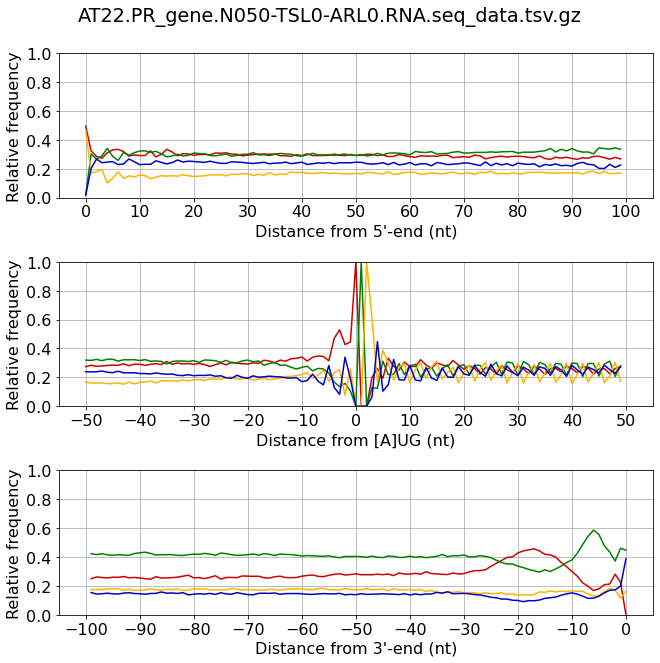

2024-08-26 11:04:39,224     INFO: Seq data |   name = AT35.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:04:39,224     INFO: Seq data |    md5 = 010f7c82fe591d99cd68f476d184876e
2024-08-26 11:04:39,224     INFO: Seq data | md5_gz = e460fe434767a99b7f1cc93cb608f96b


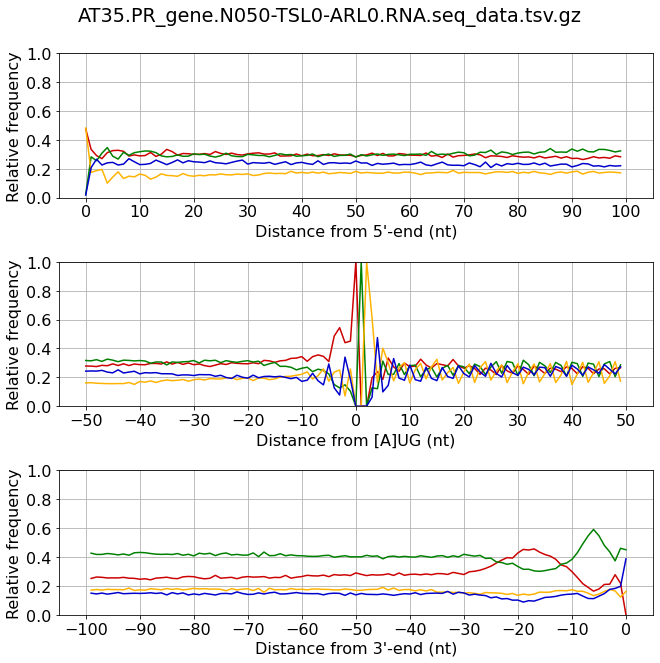

In [18]:
file_path_list = [
    os.path.join(output_dir, "AT22.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz"),
    os.path.join(output_dir, "AT35.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz"),
]
for file_path in file_path_list:
    plot_seqs(file_path, value_type=None)


---
## 上位と下位の例


2024-08-26 11:05:09,938     INFO: Seq data |   name = AT22.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:05:09,939     INFO: Seq data |    md5 = de853db935653b260b9f298b3d5e15e1
2024-08-26 11:05:09,939     INFO: Seq data | md5_gz = d82f39bf3b2742b5a916a76a64cfde64


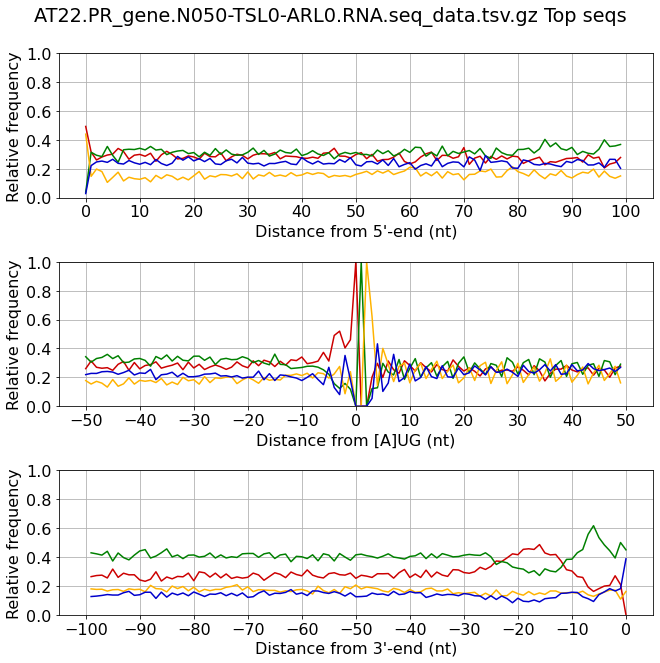

2024-08-26 11:05:10,255     INFO: Seq data |   name = AT22.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:05:10,270     INFO: Seq data |    md5 = de853db935653b260b9f298b3d5e15e1
2024-08-26 11:05:10,271     INFO: Seq data | md5_gz = d82f39bf3b2742b5a916a76a64cfde64


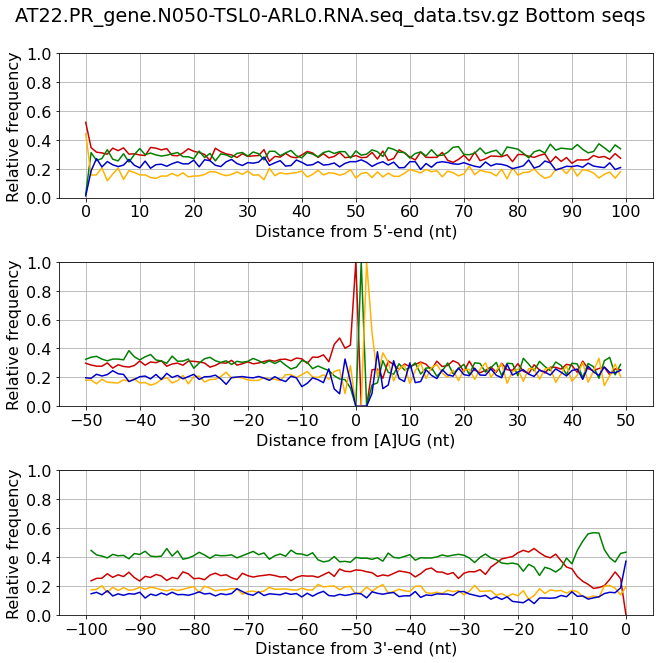

2024-08-26 11:05:10,491     INFO: Seq data |   name = AT35.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:05:10,491     INFO: Seq data |    md5 = 010f7c82fe591d99cd68f476d184876e
2024-08-26 11:05:10,491     INFO: Seq data | md5_gz = e460fe434767a99b7f1cc93cb608f96b


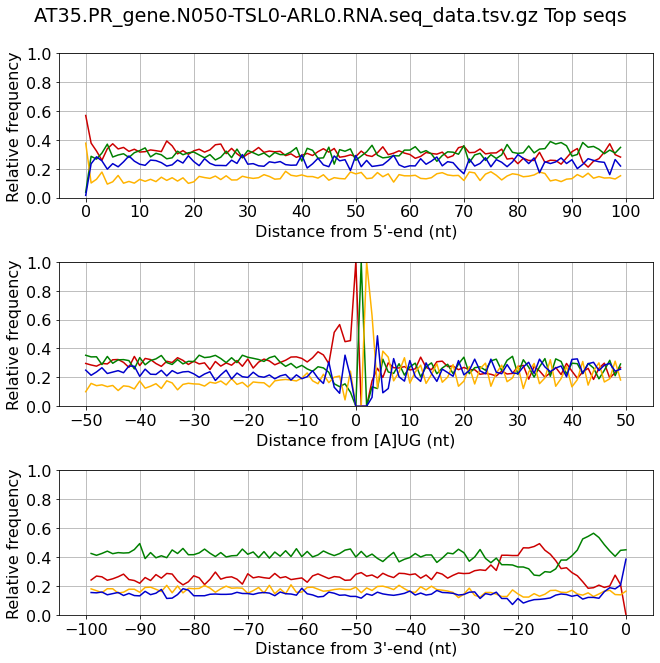

2024-08-26 11:05:10,697     INFO: Seq data |   name = AT35.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:05:10,698     INFO: Seq data |    md5 = 010f7c82fe591d99cd68f476d184876e
2024-08-26 11:05:10,698     INFO: Seq data | md5_gz = e460fe434767a99b7f1cc93cb608f96b


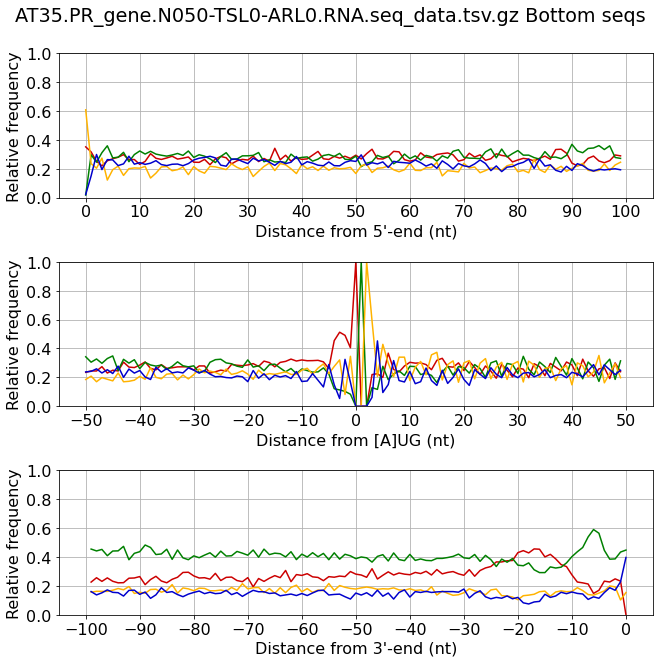

In [20]:
file_path = os.path.join(output_dir, "AT22.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz")

plot_seqs(file_path, value_type="top")
plot_seqs(file_path, value_type="bottom")

file_path = os.path.join(output_dir, "AT35.PR_gene.N050-TSL0-ARL0.RNA.seq_data.tsv.gz")

plot_seqs(file_path, value_type="top")
plot_seqs(file_path, value_type="bottom")
